In [1]:
import requests
import os

# --- CẤU HÌNH ---
date = "20260401"  # Thay bằng ngày hiện tại
cycle = "00"       # Chu kỳ chạy (00, 06, 12, 18)
forecast_hours = range(0, 27, 3)  # Lấy từ f000 đến f024, bước nhảy 3 tiếng
output_dir = "weather_data"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Các biến muốn lấy
variables = "&var_APCP=on&var_TCDC=on&var_SNOD=on"
# Các tầng muốn lấy (surface và entire atmosphere)
levels = "&lev_surface=on&lev_entire_atmosphere=on"

for hour in forecast_hours:
    f_str = f"{hour:03d}" # Chuyển 0 thành 000, 3 thành 003
    file_name = f"gfs.t{cycle}z.pgrb2.0p25.f{f_str}"
    
    # Tạo URL filter
    url = (f"https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_0p25.pl?"
           f"file={file_name}{variables}{levels}"
           f"&dir=%2Fgfs.{date}%2F{cycle}%2Fatmos")
    
    print(f"Đang tải {file_name}...")
    r = requests.get(url)
    
    if r.status_code == 200:
        with open(f"{output_dir}/{file_name}.grib2", "wb") as f:
            f.write(r.content)
    else:
        print(f"Lỗi khi tải {file_name}: {r.status_code}")

print("Hoàn thành!")

Đang tải gfs.t00z.pgrb2.0p25.f000...
Đang tải gfs.t00z.pgrb2.0p25.f003...
Đang tải gfs.t00z.pgrb2.0p25.f006...
Đang tải gfs.t00z.pgrb2.0p25.f009...
Đang tải gfs.t00z.pgrb2.0p25.f012...
Đang tải gfs.t00z.pgrb2.0p25.f015...
Đang tải gfs.t00z.pgrb2.0p25.f018...
Đang tải gfs.t00z.pgrb2.0p25.f021...
Đang tải gfs.t00z.pgrb2.0p25.f024...
Hoàn thành!


## Mo phong mua co ban (hien thi dep)
Cell ben duoi se doc cac file GFS da tai, trich xuat bien mua tich luy (`APCP/tp`), tinh tong mua theo chuoi du bao, va ve ban do mua voi ky thuat lam dep hinh anh.

In [2]:
# Neu thieu thu vien, bo comment dong sau de cai:
# %pip install -q numpy xarray cfgrib matplotlib scipy

import glob
import os
import numpy as np
import xarray as xr
import cfgrib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

Da doc 9 file
Nguon du lieu mua: APCP/tp
Rain total (mm/proxy) min/max: 0.000 / 197.438


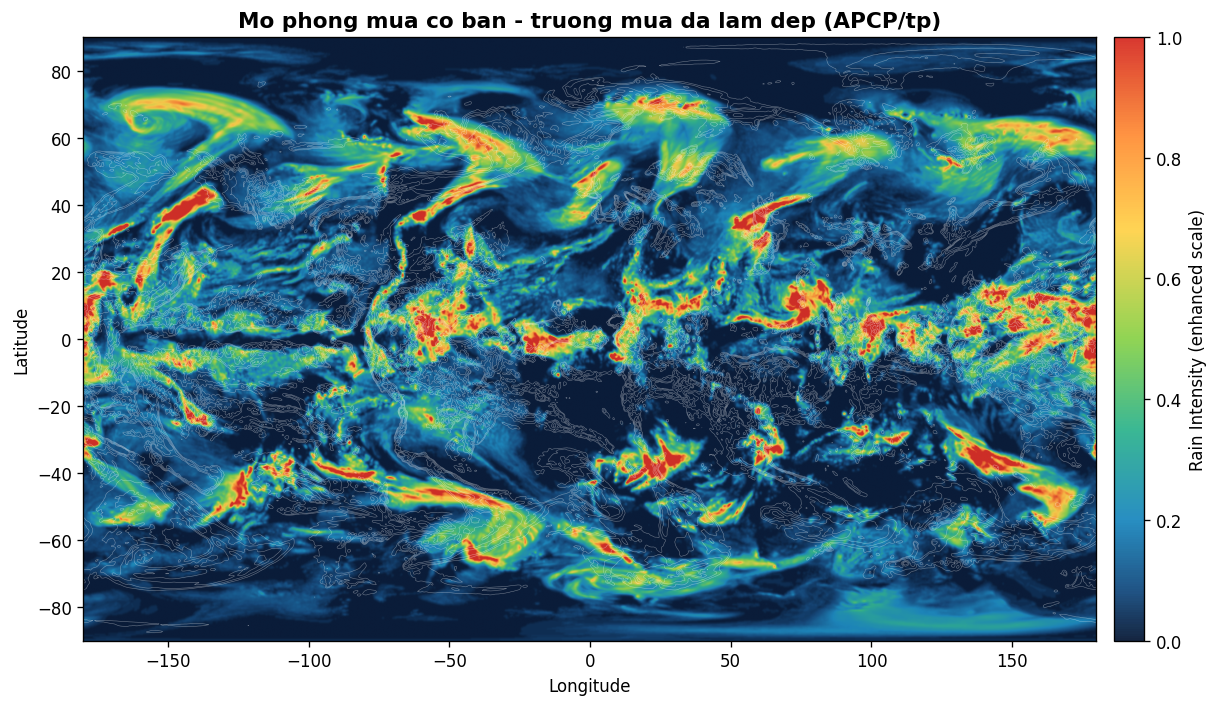

In [5]:
def _to_2d_latlon(da: xr.DataArray) -> xr.DataArray:
    da = da.squeeze(drop=True)
    for dim in list(da.dims):
        if dim not in ("latitude", "longitude", "lat", "lon"):
            da = da.isel({dim: 0})

    rename_map = {}
    if "lat" in da.dims:
        rename_map["lat"] = "latitude"
    if "lon" in da.dims:
        rename_map["lon"] = "longitude"
    if rename_map:
        da = da.rename(rename_map)

    if da.longitude.max() > 180:
        da = da.assign_coords(longitude=((da.longitude + 180) % 360) - 180).sortby("longitude")

    return da


def _pick_da(file_path: str, names, short_names=None):
    short_names = short_names or []
    ds_list = cfgrib.open_datasets(file_path)

    for ds in ds_list:
        for name in ds.data_vars:
            if name in names or name.lower() in {x.lower() for x in names}:
                return _to_2d_latlon(ds[name])

    for ds in ds_list:
        for _, da in ds.data_vars.items():
            short = str(da.attrs.get("GRIB_shortName", "")).lower()
            if short in {x.lower() for x in short_names}:
                return _to_2d_latlon(da)

    return None


def load_rain_or_proxy(files):
    precip_fields = []
    tcc_fields = []
    lat = lon = None

    for f in files:
        p_da = _pick_da(f, names=["tp", "apcp", "APCP", "prate", "acpcp"], short_names=["tp", "apcp", "prate", "acpcp"])
        c_da = _pick_da(f, names=["tcc", "TCDC"], short_names=["tcc", "tcdc"])

        if p_da is not None:
            precip_fields.append(np.asarray(p_da.values, dtype=np.float32))
            lat, lon = p_da.latitude.values, p_da.longitude.values

        if c_da is not None:
            c = np.asarray(c_da.values, dtype=np.float32)
            if np.nanmax(c) > 1.5:
                c = c / 100.0
            c = np.clip(c, 0.0, 1.0)
            tcc_fields.append(c)
            if lat is None:
                lat, lon = c_da.latitude.values, c_da.longitude.values

    if lat is None or lon is None:
        raise ValueError("Khong tim duoc du lieu lat/lon hop le")

    if len(precip_fields) >= 2:
        stack = np.stack(precip_fields, axis=0)
        stack = np.nan_to_num(stack, nan=0.0)
        diffs = np.diff(stack, axis=0, prepend=stack[0:1])
        diffs = np.clip(diffs, 0.0, None)
        total = np.sum(diffs, axis=0)
        source = "APCP/tp"
    elif len(tcc_fields) >= 1:
        # Fallback: mo phong mua tu tong may (TCDC) khi file khong co APCP.
        cstack = np.stack(tcc_fields, axis=0)
        cloud_mean = np.nanmean(cstack, axis=0)
        cloud_mean = gaussian_filter(np.clip(cloud_mean, 0.0, 1.0), sigma=1.2)

        conv_core = np.clip(cloud_mean - gaussian_filter(cloud_mean, sigma=3.2), 0.0, None)
        rain_proxy = np.clip(0.55 * cloud_mean + 1.35 * conv_core, 0.0, 1.0)
        total = rain_proxy * 35.0  # pseudo-mm de de doc
        source = "TCDC-proxy"
    else:
        raise ValueError("Khong tim thay APCP hoac TCDC trong cac file")

    return total, lat, lon, source


def enhance_rain_field(total_rain):
    rain = np.nan_to_num(total_rain, nan=0.0)

    # 1) Lam muot nhe de tranh hat noise.
    s1 = gaussian_filter(rain, sigma=1.0)

    # 2) Unsharp mask nhe de giu vung mua cuc bo ro hon.
    base = gaussian_filter(s1, sigma=2.6)
    detail = np.clip(s1 - base, 0.0, None)
    enhanced = np.clip(s1 + 0.45 * detail, 0.0, None)

    # 3) Cat nguong percentile de tranh 1 diem cuc tri lam mat do tuong phan.
    p99 = np.percentile(enhanced, 99.0)
    scale = p99 if p99 > 1e-6 else np.max(enhanced) + 1e-6
    norm = np.clip(enhanced / scale, 0.0, 1.0)

    # 4) Gamma de lam ro vung mua vua-va-lon.
    vis = np.clip(norm ** 0.62, 0.0, 1.0)
    return enhanced, vis


def plot_rain_beauty(lat, lon, rain_mm, vis, source_name):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "rain_pretty",
        [
            (0.00, "#0b1d3a"),
            (0.08, "#174c7f"),
            (0.20, "#1f8ac0"),
            (0.35, "#33b58f"),
            (0.50, "#8cd34d"),
            (0.68, "#ffd34d"),
            (0.84, "#ff8f3a"),
            (1.00, "#d73027"),
        ],
    )

    fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
    ax.set_facecolor("#081427")

    im = ax.imshow(
        vis,
        extent=[float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())],
        origin="lower",
        cmap=cmap,
        interpolation="bilinear",
        alpha=0.96,
        aspect="auto",
    )

    if np.any(rain_mm > 0):
        lv = np.quantile(rain_mm[rain_mm > 0], [0.60, 0.75, 0.88, 0.95])
    else:
        lv = [0.1, 0.2, 0.3, 0.5]
    ax.contour(lon, lat, rain_mm, levels=np.unique(np.round(lv, 3)), colors="white", linewidths=0.35, alpha=0.38)

    cbar = plt.colorbar(im, ax=ax, pad=0.015)
    cbar.set_label("Rain Intensity (enhanced scale)")

    ax.set_title(f"Mo phong mua co ban - truong mua da lam dep ({source_name})", fontsize=13, weight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()


files = sorted(glob.glob(os.path.join("weather_data", "gfs.t00z.pgrb2.0p25.f*.grib2")))
if not files:
    raise FileNotFoundError("Khong tim thay file .grib2 trong weather_data")

rain_total_mm, lat, lon, source_name = load_rain_or_proxy(files)
rain_enhanced_mm, rain_vis = enhance_rain_field(rain_total_mm)

print(f"Da doc {len(files)} file")
print(f"Nguon du lieu mua: {source_name}")
print(f"Rain total (mm/proxy) min/max: {rain_total_mm.min():.3f} / {rain_total_mm.max():.3f}")
plot_rain_beauty(lat, lon, rain_enhanced_mm, rain_vis, source_name)